In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing

import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
df = pd.read_csv('cleaned_data.csv')

std_scale = preprocessing.StandardScaler()

# Etude Stabilité clusters

## PRIMAL CLUSTERING

In [ ]:
# Preprocessing

df = df.dropna()
df = df.reset_index(drop=True)

start_date = pd.Timestamp("2016-09-15")
end_date = start_date + pd.Timedelta(days=365)

df_period = df[(df["order_date"] >= start_date) & (df["order_date"] <= end_date)].copy()

# Groupby avec agg( review_score_mean=('review_score', 'mean'), order_total_sum=('order_total', 'sum'), delay_days_mean=('delay_days', 'mean') )
df_period_gr = df_period.groupby(by="customer_unique_id").agg(
    review_score_mean=('review_score', 'mean'),
    order_total_sum=('order_total', 'sum'),
    delay_days_mean=('delay_days', 'mean'),
    last_order_date=('order_date', 'max'),
).reset_index()

#  A faire sur la colonne delay_days 
df_period_gr['delay_days_mean'] = df_period_gr['delay_days_mean'].dt.total_seconds() / (24*60*60)

#  Création colonne : nouveau calcul récence avec nouvelle end_date
df_period_gr['recency'] = (end_date - df_period_gr['last_order_date']).dt.days

In [ ]:
# Scaling et Predictions

features = ["delay_days_mean", "order_total_sum", "review_score_mean", "recency"]

df_period_gr = df_period_gr.set_index("customer_unique_id")

X_scaled = std_scale.fit_transform(df_period_gr[features])

client_ids_list = df_period_gr.index.unique().tolist()

kmeans_model = KMeans(n_clusters=6, random_state=32)
clusters = kmeans_model.fit_predict(X_scaled)

df_period_gr["cluster"] = clusters

df_period_gr_clusters = df_period_gr["cluster"]

df_period_gr_clusters = df_period_gr_clusters.reset_index()

## ITERATED ANALYSIS

In [ ]:
def preprocessor_helper(df, timelapse_duration : 30, client_ids_list, start_date="2016-09-15", n=1):

    df = df.dropna()
    df = df.reset_index(drop=True)

    st_date = pd.Timestamp(start_date)
    en_date = st_date + pd.Timedelta(days=365) + (pd.Timedelta(days=timelapse_duration * n))

    max_date = df["order_date"].max()
    if en_date > max_date:
        # Return None and False to indicate end of data
        return None, en_date ,False

    df_period_2 = df[(df["order_date"] >= st_date) & (df["order_date"] <= en_date)].copy()

    # remove uncommon clients
    df_period_2 = df_period_2[df_period_2['customer_unique_id'].isin(client_ids_list)]

    # Groupby avec agg( review_score_mean=('review_score', 'mean'), order_total_sum=('order_total', 'sum'), delay_days_mean=('delay_days', 'mean') )
    df_period_2_gr = df_period_2.groupby(by="customer_unique_id").agg(
        review_score_mean=('review_score', 'mean'),
        order_total_sum=('order_total', 'sum'),
        delay_days_mean=('delay_days', 'mean'),
        last_order_date=('order_date', 'max'),
    ).reset_index()

    #  A faire sur la colonne delay_days 
    df_period_2_gr['delay_days_mean'] = df_period_2_gr['delay_days_mean'].dt.total_seconds() / (24*60*60)

    #  Création colonne : nouveau calcul récence avec nouvelle end_date
    df_period_2_gr['recency'] = (en_date - df_period_2_gr['last_order_date']).dt.days

    return df_period_2_gr, en_date, True

In [ ]:
def predictions(scaler_model, kmeans_model, df_2):

    #  - Scaling (pas fit, just transform)
    features = ["delay_days_mean", "order_total_sum", "review_score_mean", "recency"]
    df_scaled = df_2.set_index("customer_unique_id")

    X_scaled = scaler_model.transform(df_scaled[features])
    clusters = kmeans_model.predict(X_scaled)

    df_scaled["cluster"] = clusters
    df_scaled_clusters = df_scaled["cluster"]
    df_scaled_clusters = df_scaled_clusters.reset_index()

    return df_scaled_clusters

In [ ]:
def comparatif(df1, df2):

    # Merge pour avoir customer_id + cluster 1 et 2
    df_common = pd.merge(
    df1[["customer_unique_id", "cluster"]],
    df2[["customer_unique_id", "cluster"]],
    on="customer_unique_id",
    suffixes=("_p1", "_p2")
    )
    
    ari = adjusted_rand_score(df_common["cluster_p1"], df_common["cluster_p2"])
    
    return ari

In [ ]:
number = 1
timelapse_duration = 30
results = []

while True:
    df_helped, end_date, continue_flag = preprocessor_helper(
        df,
        timelapse_duration=timelapse_duration,
        client_ids_list=client_ids_list,
        n=number
    )

    if not continue_flag:
        print(f"Reached beyond dataset at {end_date.date()} — stopping.")
        break

    df_helped_clusters = predictions(scaler_model=std_scale, kmeans_model=kmeans_model, df_2=df_helped)
    ari = comparatif(df1=df_period_gr_clusters, df2=df_helped_clusters)

    results.append({
        "iteration": number,
        "end_date": end_date,
        "ari": ari
    })

    print(f"Iteration {number} — End date: {end_date.date()} — ARI: {ari:.4f}")

    number += 1

monthly_results_df = pd.DataFrame(results)

Iteration 1 — End date: 2017-10-15 — ARI: 0.6291
Iteration 2 — End date: 2017-11-14 — ARI: 0.3703
Iteration 3 — End date: 2017-12-14 — ARI: 0.3644
Iteration 4 — End date: 2018-01-13 — ARI: 0.4059
Iteration 5 — End date: 2018-02-12 — ARI: 0.4041
Iteration 6 — End date: 2018-03-14 — ARI: 0.3425
Iteration 7 — End date: 2018-04-13 — ARI: 0.2146
Iteration 8 — End date: 2018-05-13 — ARI: 0.1027
Iteration 9 — End date: 2018-06-12 — ARI: 0.0545
Iteration 10 — End date: 2018-07-12 — ARI: 0.0417
Iteration 11 — End date: 2018-08-11 — ARI: 0.0389
Reached beyond dataset at 2018-09-10 — stopping.


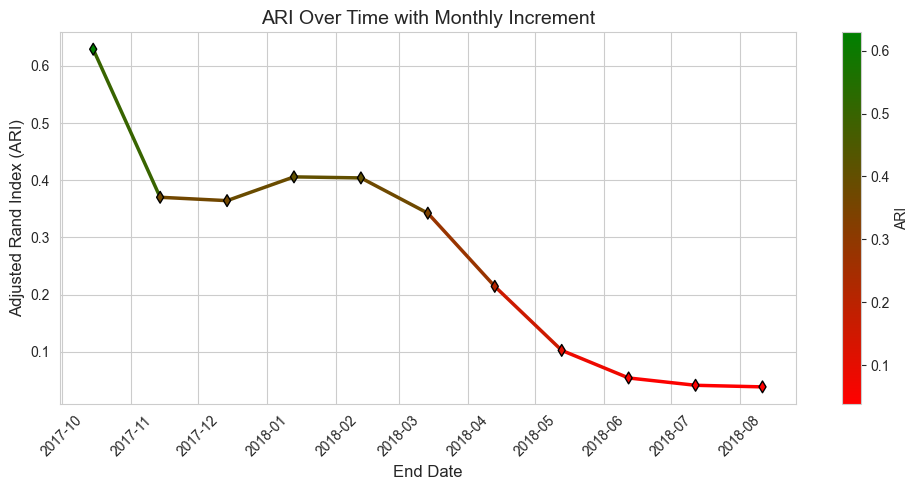

In [ ]:
monthly_results_df["end_date"] = pd.to_datetime(monthly_results_df["end_date"])

cmap = LinearSegmentedColormap.from_list("red_to_green", ["red", "green"])

norm = mcolors.Normalize(vmin=monthly_results_df["ari"].min(), vmax=monthly_results_df["ari"].max())

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(1, len(monthly_results_df)):
    x = [monthly_results_df["end_date"].iloc[i-1], monthly_results_df["end_date"].iloc[i]]
    y = [monthly_results_df["ari"].iloc[i-1], monthly_results_df["ari"].iloc[i]]
    color = cmap(norm((monthly_results_df["ari"].iloc[i-1] + monthly_results_df["ari"].iloc[i]) / 2))
    ax.plot(x, y, color=color, linewidth=2.5)

sc = ax.scatter(monthly_results_df["end_date"], monthly_results_df["ari"], c=monthly_results_df["ari"], cmap=cmap, norm=norm, edgecolor='k', zorder=3, marker="d")

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("ARI")

ax.set_title("ARI Over Time with Monthly Increment", fontsize=14)
ax.set_xlabel("End Date", fontsize=12)
ax.set_ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.xticks(rotation=45)
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
number = 1
timelapse_duration = 7
results = []

while True:
    df_helped, end_date, continue_flag = preprocessor_helper(
        df,
        timelapse_duration=timelapse_duration,
        client_ids_list=client_ids_list,
        n=number
    )

    if not continue_flag:
        print(f"Reached beyond dataset at {end_date.date()} — stopping.")
        break

    df_helped_clusters = predictions(scaler_model=std_scale, kmeans_model=kmeans_model, df_2=df_helped)
    ari = comparatif(df1=df_period_gr_clusters, df2=df_helped_clusters)

    results.append({
        "iteration": number,
        "end_date": end_date,
        "ari": ari
    })

    print(f"Iteration {number} — End date: {end_date.date()} — ARI: {ari:.4f}")

    number += 1

weekly_results_df = pd.DataFrame(results)

Iteration 1 — End date: 2017-09-22 — ARI: 0.9064
Iteration 2 — End date: 2017-09-29 — ARI: 0.8229
Iteration 3 — End date: 2017-10-06 — ARI: 0.7350
Iteration 4 — End date: 2017-10-13 — ARI: 0.6522
Iteration 5 — End date: 2017-10-20 — ARI: 0.5671
Iteration 6 — End date: 2017-10-27 — ARI: 0.4926
Iteration 7 — End date: 2017-11-03 — ARI: 0.4352
Iteration 8 — End date: 2017-11-10 — ARI: 0.3907
Iteration 9 — End date: 2017-11-17 — ARI: 0.3585
Iteration 10 — End date: 2017-11-24 — ARI: 0.3421
Iteration 11 — End date: 2017-12-01 — ARI: 0.3381
Iteration 12 — End date: 2017-12-08 — ARI: 0.3468
Iteration 13 — End date: 2017-12-15 — ARI: 0.3686
Iteration 14 — End date: 2017-12-22 — ARI: 0.3987
Iteration 15 — End date: 2017-12-29 — ARI: 0.4041
Iteration 16 — End date: 2018-01-05 — ARI: 0.4046
Iteration 17 — End date: 2018-01-12 — ARI: 0.4052
Iteration 18 — End date: 2018-01-19 — ARI: 0.4076
Iteration 19 — End date: 2018-01-26 — ARI: 0.4076
Iteration 20 — End date: 2018-02-02 — ARI: 0.4080
Iteration

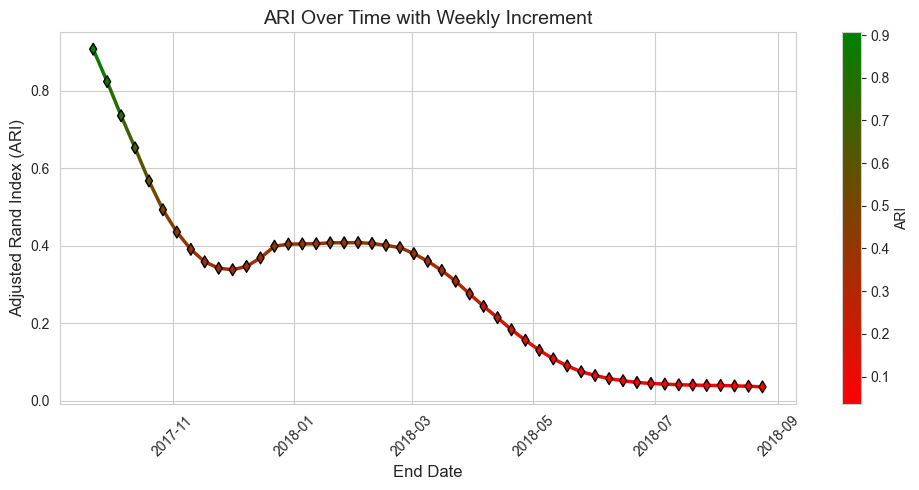

In [ ]:
weekly_results_df["end_date"] = pd.to_datetime(weekly_results_df["end_date"])

cmap = LinearSegmentedColormap.from_list("red_to_green", ["red", "green"])

norm = mcolors.Normalize(vmin=weekly_results_df["ari"].min(), vmax=weekly_results_df["ari"].max())

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(1, len(weekly_results_df)):
    x = [weekly_results_df["end_date"].iloc[i-1], weekly_results_df["end_date"].iloc[i]]
    y = [weekly_results_df["ari"].iloc[i-1], weekly_results_df["ari"].iloc[i]]
    color = cmap(norm((weekly_results_df["ari"].iloc[i-1] + weekly_results_df["ari"].iloc[i]) / 2))
    ax.plot(x, y, color=color, linewidth=2.5)

sc = ax.scatter(weekly_results_df["end_date"], weekly_results_df["ari"], c=weekly_results_df["ari"], cmap=cmap, norm=norm, edgecolor='k', zorder=3, marker="d")

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("ARI")

ax.set_title("ARI Over Time with Weekly Increment", fontsize=14)
ax.set_xlabel("End Date", fontsize=12)
ax.set_ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.xticks(rotation=45)
ax.grid(True)
plt.tight_layout()
plt.show()

# END